<a href="https://colab.research.google.com/github/esprado1976/ChurnAnallisys/blob/main/AnalisisChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Pega aquí la ruta que copiaste
ruta_archivo = '/content/drive/MyDrive/Datasets/telco_customer_churn.csv'

# Cargar el CSV
df = pd.read_csv(ruta_archivo)

# Mostrar las primeras filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# Resumen técnico: tipos de datos y valores no nulos
df.info()

# Estadísticas descriptivas (media, desviación, min/max)
df.describe()

# Verificar valores nulos por columna
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Opción rápida: eliminar filas con nulos en esa columna
df.dropna(subset=['TotalCharges'], inplace=True)

¿En qué mes perdemos a la mayoría de los clientes?

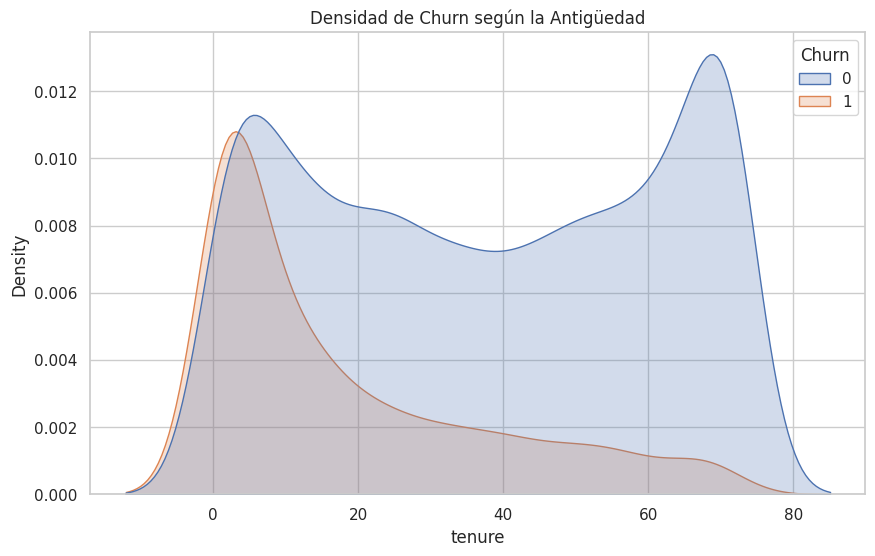

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)
plt.title('Densidad de Churn según la Antigüedad')
plt.show()

Relación Categórica: TechSupport vs Churn

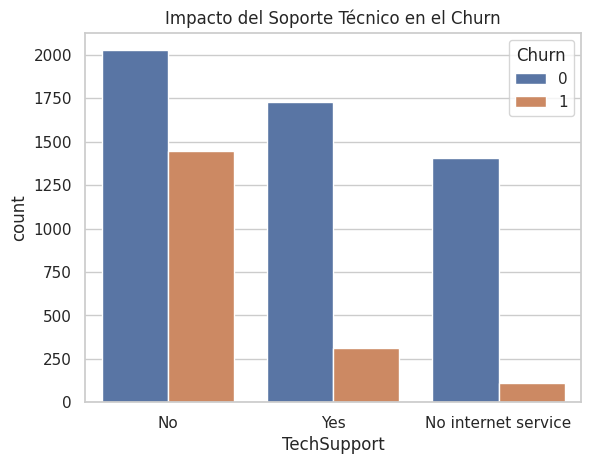

In [10]:
# Gráfico de barras apiladas o comparativas
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Impacto del Soporte Técnico en el Churn')
plt.show()

¿Los que se van pagaban más en promedio?

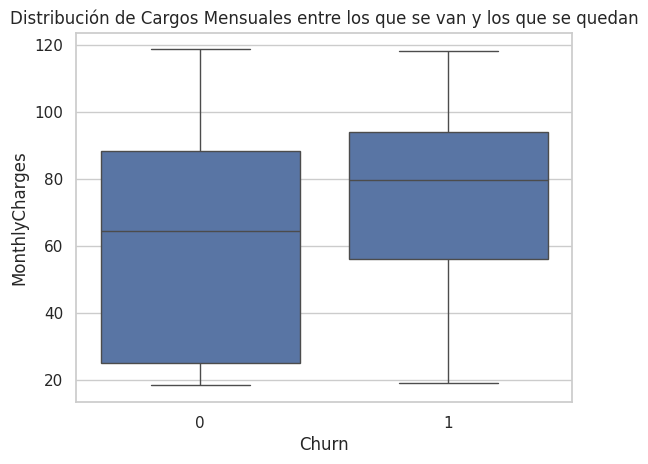

In [11]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Distribución de Cargos Mensuales entre los que se van y los que se quedan')
plt.show()

relacion de charges y monthly charges

La correlación entre cargos mensuales e históricos es: 0.65


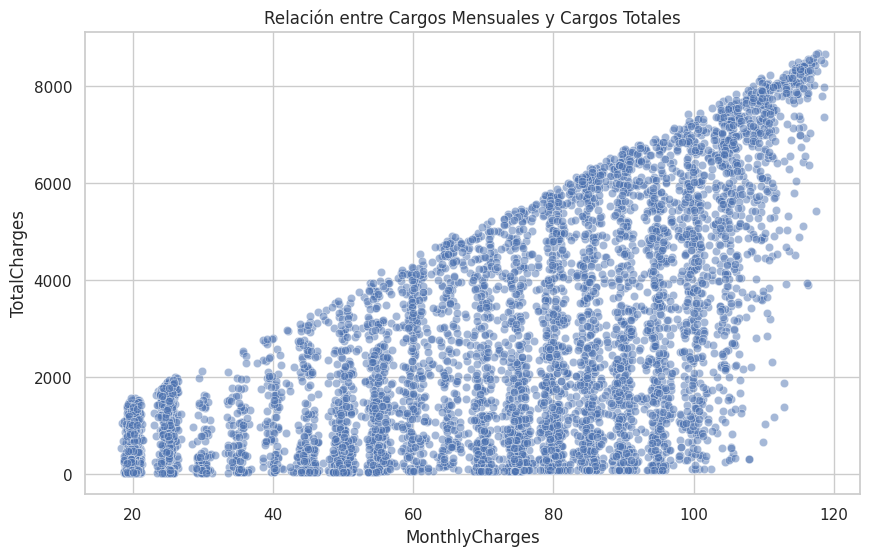

In [12]:
# 1. Calculamos la correlación de Pearson
correlacion = df['MonthlyCharges'].corr(df['TotalCharges'])
print(f"La correlación entre cargos mensuales e históricos es: {correlacion:.2f}")

# 2. Visualización con un Scatter Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', alpha=0.5)
plt.title('Relación entre Cargos Mensuales y Cargos Totales')
plt.show()

Encoding de las cariables categóricas

In [13]:
# Seleccionamos las columnas que elegiste analizar + Churn
columnas_interes = ['tenure', 'TechSupport', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
df_modelo = df[columnas_interes].copy()

# Convertimos variables de texto a números (Variables Dummy)
df_final = pd.get_dummies(df_modelo, columns=['TechSupport', 'PaymentMethod'], drop_first=True)

# Veamos cómo quedó la estructura
print(df_final.head())

   tenure  MonthlyCharges  TotalCharges  Churn  \
0       1           29.85         29.85      0   
1      34           56.95       1889.50      0   
2       2           53.85        108.15      1   
3      45           42.30       1840.75      0   
4       2           70.70        151.65      1   

   TechSupport_No internet service  TechSupport_Yes  \
0                            False            False   
1                            False            False   
2                            False            False   
3                            False             True   
4                            False            False   

   PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
0                                  False                            True   
1                                  False                           False   
2                                  False                           False   
3                                  False                        

Establecemos las variables que vamos a analizar para predecir el churn (Y)

In [14]:
# Definimos la variable objetivo (y)
y = df_final['Churn']

# Definimos las variables predictoras (X)
# Eliminamos 'Churn' de las X porque es lo que queremos predecir
X = df_final.drop('Churn', axis=1)

print(f"Forma de X (Predictoras): {X.shape}")
print(f"Forma de y (Objetivo): {y.shape}")

Forma de X (Predictoras): (7032, 8)
Forma de y (Objetivo): (7032,)


Dividimos conjunto de entrenamiento y prueba

In [15]:
from sklearn.model_selection import train_test_split

# Dividimos: 80% para entrenar y 20% para testear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Registros para entrenar: {len(X_train)}")
print(f"Registros para validar: {len(X_test)}")

Registros para entrenar: 5625
Registros para validar: 1407


Usamos stratify=y para asegurar que el porcentaje de personas que se van (Churn=1) sea el mismo en ambos grupos.

vamos a utilizar un modelo de Random Ferest para la predicción de churn

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear el modelo con 100 árboles
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar con los datos de entrenamiento
modelo_rf.fit(X_train, y_train)

# Realizar predicciones sobre el set de prueba
y_pred = modelo_rf.predict(X_test)

Revisamos el resultado

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.58      0.49      0.53       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407



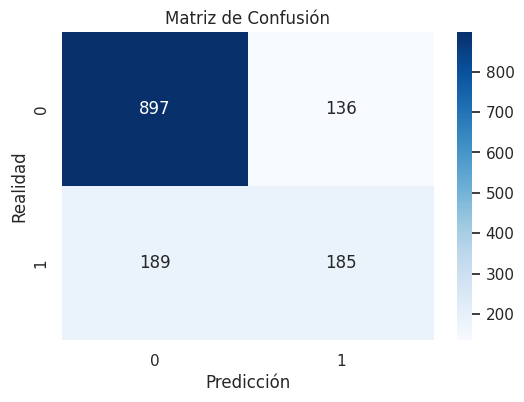

In [17]:
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusión para ver aciertos y errores
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

Veamos como pesaron las variables

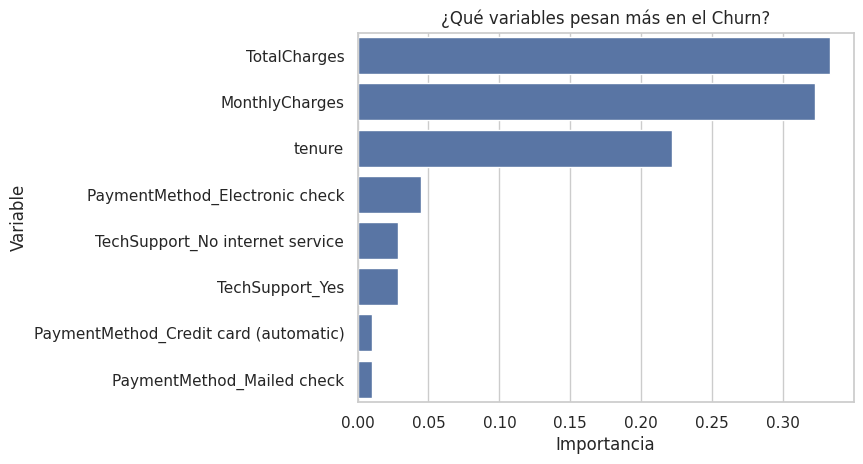

In [18]:
importances = modelo_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances}).sort_values(by='Importancia', ascending=False)

sns.barplot(data=feature_importance_df, x='Importancia', y='Variable')
plt.title('¿Qué variables pesan más en el Churn?')
plt.show()

Viendo el desbalanceo de clases en el churn,  vamos a usar el parámetro class_weight='balanced'. Esto penaliza más al modelo cuando se equivoca con un cliente que hace Churn.

In [19]:
# Entrenamos de nuevo pero equilibrando las clases automáticamente
modelo_rf_ajustado = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,        # Limitamos profundidad para no sobreajustar
    class_weight='balanced',
    random_state=42
)

modelo_rf_ajustado.fit(X_train, y_train)
y_pred_ajustado = modelo_rf_ajustado.predict(X_test)

print(classification_report(y_test, y_pred_ajustado))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



Ajustamos con GridSearchCV

In [21]:
from sklearn.model_selection import GridSearchCV

# Definimos los parámetros que queremos que pruebe
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

# Configuramos la búsqueda enfocándonos en mejorar el RECALL
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall', # Aquí le decimos qué métrica nos importa más
    cv=3,             # 3 vueltas de validación cruzada
    verbose=1,
    n_jobs=-1         # Usa todos los procesadores para ir más rápido
)

# Ejecutamos la búsqueda (esto puede tardar un minuto)
grid_search.fit(X_train, y_train)

# Vemos cuáles fueron los mejores parámetros
print("Mejor configuración encontrada:", grid_search.best_params_)

# Evaluamos el mejor modelo encontrado
mejor_modelo = grid_search.best_estimator_
y_pred_grid = mejor_modelo.predict(X_test)
print(classification_report(y_test, y_pred_grid))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Mejor configuración encontrada: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



Una vez que mejoramos el recall, vamos a establecer un ranking de probabilidad de churn

In [22]:
# 1. Obtenemos las probabilidades de Churn (tomamos la columna del '1')
probabilidades = mejor_modelo.predict_proba(X_test)[:, 1]

# 2. Creamos un DataFrame con los resultados
# Usamos el índice de X_test para recuperar los IDs originales si los tienes
resultados = pd.DataFrame({
    'Probabilidad_Churn': probabilidades,
    'Prediccion_Final': y_pred_grid
}, index=X_test.index)

# 3. Unimos con los datos originales para tener el ID del cliente
# (Asumiendo que tu df original tenía una columna 'customerID')
reporte_riesgo = resultados.join(df[['customerID', 'tenure', 'MonthlyCharges']])

# 4. Ordenamos por los de mayor riesgo primero
reporte_riesgo = reporte_riesgo.sort_values(by='Probabilidad_Churn', ascending=False)

# 5. Guardamos en un CSV para descargar
reporte_riesgo.to_csv('clientes_en_riesgo.csv', index=False)

print("¡Archivo 'clientes_en_riesgo.csv' generado con éxito!")
reporte_riesgo.head(10)

¡Archivo 'clientes_en_riesgo.csv' generado con éxito!


,Probabilidad_Churn,Prediccion_Final,customerID,tenure,MonthlyCharges
3380,0.894017,1,5178-LMXOP,1,95.10
6240,0.894017,1,6521-YYTYI,1,93.30
4585,0.893717,1,1069-XAIEM,1,85.05
642,0.892988,1,0970-ETWGE,1,89.55
2397,0.892988,1,3722-WPXTK,1,88.35
680,0.892385,1,1448-PWKYE,1,80.00
6190,0.892385,1,2867-UIMSS,1,80.50
3906,0.890727,1,6372-RFVNS,1,78.80
5706,0.890727,1,5196-SGOAK,1,75.70
2464,0.890727,1,2609-IAICY,1,77.15


Con esto realizado, guardamos el modelo entrenado

In [23]:
import joblib

# Guardamos el modelo en un archivo .pkl
joblib.dump(mejor_modelo, 'modelo_churn_rf_optimizado.pkl')

print("Modelo guardado. En el futuro, solo necesitas cargarlo con joblib.load()")

Modelo guardado. En el futuro, solo necesitas cargarlo con joblib.load()
